# Building an Efficient Frontier and Optimal Portfolio from SENSEX Stocks

---

# Objective:

The objective of this project is to construct an optimal risk-adjusted portfolio by selecting 10 stocks from the top 30 companies listed in the SENSEX index, using three years of historical data. The portfolio is optimized using the Sharpe ratio, and its performance is backtested over the following one-year period against the SENSEX and a naive (equally weighted) portfolio.

---

# Methodology:

- Data Collection:

    - Stock price data for the 30 SENSEX companies were downloaded using Yahoo Finance (ticker symbols suffixed with ".NS" for NSE).

    - The training period was from April 1, 2021, to April 1, 2024.

    - The backtesting period was from April 2, 2024, to April 1, 2025.

- Data Preparation:

    - Daily returns were computed for both the training and backtesting periods.

    - Annualized mean returns and the annualized covariance matrix were calculated for the training period.

- Portfolio Simulation:

    - A Monte Carlo simulation was performed to generate 1 million random portfolios.

    - Each portfolio consisted of exactly 10 different stocks (no repetition), with randomly assigned weights normalized to sum to 1.

    - For each simulated portfolio, the expected annualized return, annualized volatility (standard deviation), and Sharpe ratio (assuming a risk-free rate of 6%) were calculated.

- Optimal Portfolio Selection:

    - The portfolio with the highest Sharpe ratio from the simulation was selected as the optimal portfolio.

    - The optimal stock weights were extracted and visualized.

- Benchmark Portfolios:

    - A SENSEX portfolio was constructed based on the official index weightages.

    - A naive portfolio was constructed by assigning equal weights to all 30 stocks.

- Efficient Frontier Visualization:

    - A scatter plot was generated showing the distribution of simulated portfolios by risk and return.

    - The optimal portfolio, SENSEX portfolio, and naïve portfolio were highlighted on the efficient frontier.

- Backtesting:

    - The cumulative returns of the optimal portfolio, SENSEX portfolio, and naive portfolio were calculated and compared over the one-year backtesting period.

    - Annualized return, annualized volatility, and Sharpe ratio were computed for all three portfolios during the backtesting period.

---

# Key Findings:

- The optimal portfolio, selected purely based on maximizing the Sharpe ratio over the training period, significantly outperformed both the SENSEX and naive portfolios during the backtesting period.

- Visualization of the efficient frontier showed that the optimal portfolio achieved a better risk-return tradeoff compared to the benchmarks.

- Annualized metrics from the backtest revealed:

- The optimal portfolio achieved the highest Sharpe ratio.

- It maintained a competitive volatility while offering superior returns compared to the SENSEX and the naïve portfolio.

---

# Conclusion:

This project demonstrates that using historical data and quantitative optimization techniques like the efficient frontier and Sharpe ratio maximization, it is possible to construct a well-diversified portfolio that outperforms a major market index. By restricting portfolio selection to a fixed number of stocks (10 out of 30), the model introduces a practical constraint often seen in real-world asset management. The backtesting results validate the effectiveness of this approach and highlight the potential benefits of disciplined, data-driven portfolio construction strategies over simple or market-weighted investment methods.

---



# Code and analysis

Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
np.random.seed(500)


I used the SENSEX index data, consisting of the top 30 companies listed on the BSE, along with their respective weights as of October 2024.

In [2]:
sensex_data=pd.read_csv("Sensex_data.csv")
sensex_data.head()


,Company Name,Stock Symbol (NSE),Weightage (%)
0,Adani Ports & Special Economic Zone Ltd,ADANIPORTS,1.09
1,Asian Paints Ltd.,ASIANPAINT,1.54
2,Axis Bank Ltd.,AXISBANK,3.61
3,Bajaj Finserv Ltd.,BAJAJFINSV,1.10
4,Bajaj Finance Ltd.,BAJFINANCE,2.21


We will use three years of stock return data as the training dataset to construct the efficient frontier and identify the optimal portfolio based on the Sharpe ratio. The following one year of data will be used for backtesting the performance of the optimal portfolio against the SENSEX index and a naïve (equally weighted) portfolio.

In [3]:

train_start = "2021-04-01"
train_end = "2024-04-01" 
test_start = "2024-04-02"
test_end = "2025-04-01"  

ticker_set = [symbol + ".NS" for symbol in sensex_data["Stock Symbol (NSE)"]]

train_data = yf.download(ticker_set, start=train_start, end=train_end)['Close']
test_data = yf.download(ticker_set, start=test_start, end=test_end)['Close']


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  30 of 30 completed


In [4]:
train_returns = train_data.pct_change().dropna()
test_returns = test_data.pct_change().dropna()

returns = train_returns.mean() * 252
cov_matrix = train_returns.cov() * 252

num_assets = len(returns)
risk_free_rate = 0.06

Monte Carlo simulation of portfolios

In [5]:
desired_portfolio_size = 10
num_sim_portfolios = 10**6
all_weights = np.zeros((num_sim_portfolios, num_assets))
ret_arr = np.zeros(num_sim_portfolios)
vol_arr = np.zeros(num_sim_portfolios)
sharpe_arr = np.zeros(num_sim_portfolios)

for i in range(num_sim_portfolios):
    weights = np.zeros(num_assets)
    non_zero_indices = np.random.choice(30, 10, replace=False)
    weights[non_zero_indices] = np.random.random(desired_portfolio_size)
    weights = weights / np.sum(weights) 
    portfolio_return = np.dot(weights, returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    portfolio_std = np.sqrt(portfolio_variance)
    
    all_weights[i, :] = weights
    ret_arr[i] = portfolio_return
    vol_arr[i] = portfolio_std
    sharpe_arr[i] = (portfolio_return - risk_free_rate) / portfolio_std


Find Optimal Portfolio

In [6]:
max_sharpe_idx = np.argmax(sharpe_arr)
optimal_weights = all_weights[max_sharpe_idx, :]


SENSEX and Naive portfolio

In [7]:
sensex_weitage = np.array(sensex_data["Weightage (%)"] / sensex_data["Weightage (%)"].sum())
sensex_returns_train = (train_returns * sensex_weitage ).sum(axis=1)

naive_weights = np.ones(num_assets) / num_assets
naive_portfolio_returns_train = (train_returns * naive_weights).sum(axis=1)


Plot Efficient Frontier

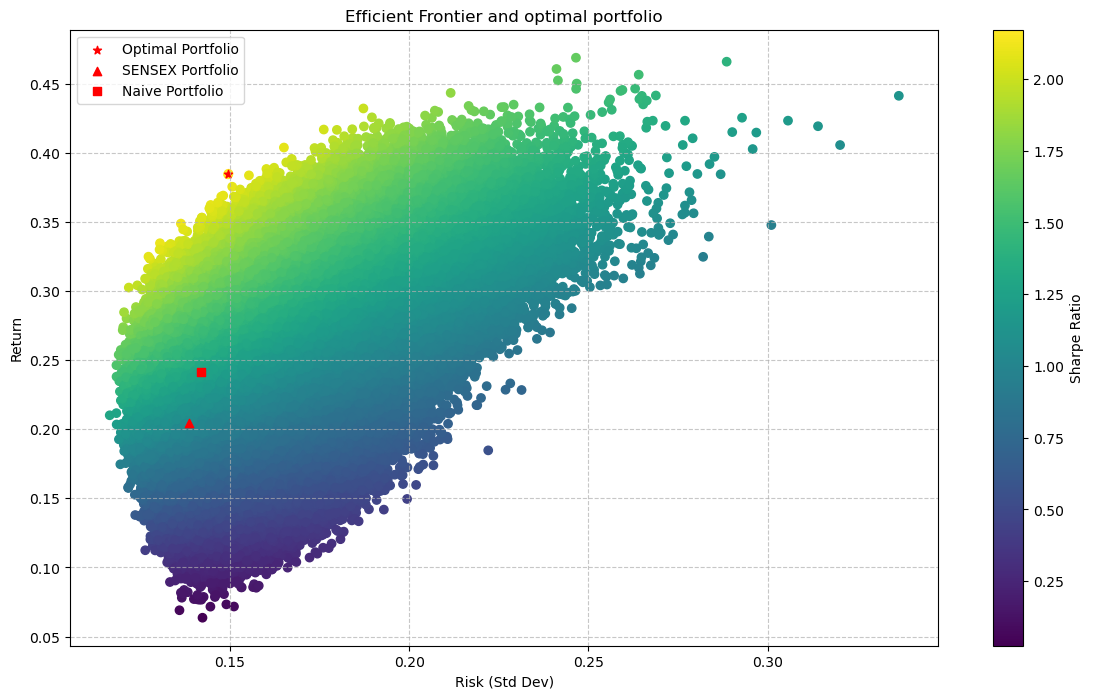

In [8]:
plt.figure(figsize=(14, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], c='red', marker='*', label='Optimal Portfolio')
plt.scatter(sensex_returns_train.std() * np.sqrt(252), sensex_returns_train.mean() * 252, c='red', marker='^', label='SENSEX Portfolio')
plt.scatter(naive_portfolio_returns_train.std() * np.sqrt(252), naive_portfolio_returns_train.mean() * 252, c='red', marker='s', label='Naive Portfolio')
plt.xlabel('Risk (Std Dev)')
plt.ylabel('Return')
plt.title('Efficient Frontier and optimal portfolio')
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.show()


Optimal Portfolio Allocation

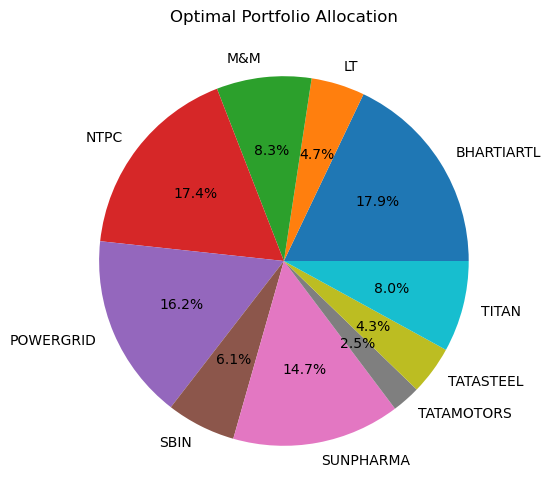

In [9]:
optimal_portfolio_allocation = optimal_weights[optimal_weights>0] *100
optimal_portfolio_stocks = sensex_data["Stock Symbol (NSE)"][optimal_weights>0]
plt.figure(figsize=(6,6))
plt.pie(optimal_portfolio_allocation, labels= optimal_portfolio_stocks, autopct='%1.1f%%')
plt.title('Optimal Portfolio Allocation')
plt.show()

Create portfolios for backtesting

In [10]:
optimal_portfolio_returns = (test_returns * optimal_weights).sum(axis=1)

naive_weights = np.ones(num_assets) / num_assets
naive_portfolio_returns = (test_returns * naive_weights).sum(axis=1)

sensex_weitage = np.array(sensex_data["Weightage (%)"] / sensex_data["Weightage (%)"].sum())
sensex_returns = (test_returns * sensex_weitage ).sum(axis=1)

Cumulative returns

In [11]:
optimal_cum_returns = (1+ optimal_portfolio_returns).cumprod()
naive_cum_returns = (1+naive_portfolio_returns).cumprod()
sensex_cum_returns = (1+sensex_returns).cumprod()

Plot Backtest Performance

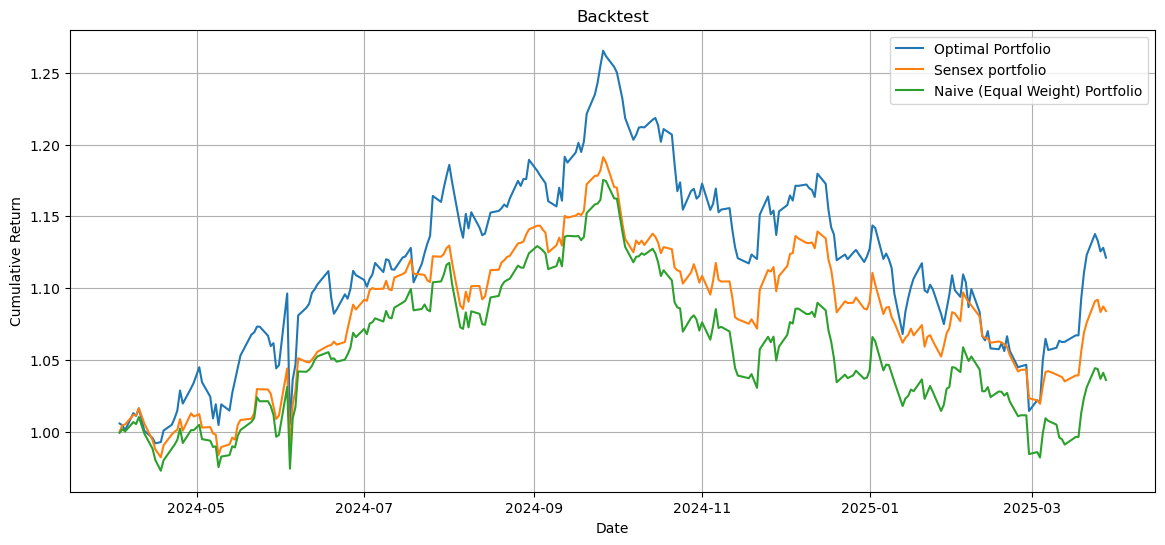

In [12]:
plt.figure(figsize=(14,6))
plt.plot(optimal_cum_returns, label="Optimal Portfolio")
plt.plot(sensex_cum_returns, label="Sensex portfolio")
plt.plot(naive_cum_returns, label="Naive (Equal Weight) Portfolio")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Backtest')
plt.legend()
plt.grid(True)
plt.savefig("efficient_portfolio.png")
plt.show()

Calculate Annualized Metrics

In [13]:
daily_return = pd.DataFrame({
    "Optimal Portfolio": optimal_portfolio_returns.values, "SENSEX portfolio":sensex_returns.values, "Naive portfolio":naive_portfolio_returns.values
}, index=optimal_portfolio_returns.index)


metrics = {}

for col in daily_return.columns:
    mean_daily_return = daily_return[col].mean()
    std_daily_return = daily_return[col].std()

    annualized_return = mean_daily_return * 252
    annualized_volatility = std_daily_return * np.sqrt(252)
    sharpe_ratio = (annualized_return-risk_free_rate) / annualized_volatility

    metrics[col] = {
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio
    }

metrics_df = pd.DataFrame(metrics).T
metrics_df["Annualized Return"] = metrics_df["Annualized Return"].apply(lambda x: f"{x*100:.2f}%")
metrics_df["Annualized Volatility"] = metrics_df["Annualized Volatility"].apply(lambda x: f"{x*100:.2f}%")
metrics_df["Sharpe Ratio"] = metrics_df["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

print(metrics_df)

                  Annualized Return Annualized Volatility Sharpe Ratio
Optimal Portfolio            13.47%                18.64%         0.40
SENSEX portfolio              9.25%                14.00%         0.23
Naive portfolio               4.71%                14.72%        -0.09
